In [ ]:
###########
#
#
#
# Figure S4
#
#
#
#
##############

In [1]:

import netCDF4 as nc4
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from scipy import stats



import glob as glob
import os
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import matplotlib.pyplot as plt
import matplotlib as mpl
from pylab import *; 
import cartopy
import cartopy.crs as ccrs
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300




ERROR 1: PROJ: proj_create_from_database: Open of /curc/sw/conda_env/atoc-2025/share/proj failed


In [20]:

#get files
these_cases=['fosi_ur_150tg_01_alluv','fosi_ur_150tg_01_ctluv','fosi_ip_46p8_01_alluv','fosi_ip_46p8_01_ctluv','fosi_ip_5tg_01_alluv','fosi_ip_5tg_01_ctluv','nw_cntrl_tuv_01']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
#these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_variables=['ATM_EPHYTO1UVA_NET','ATM_EPHYTO1UVB_NET','ATM_EPHYTO1UVC_NET']


files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   
       
example_file=files[case][VAR][0]

In [21]:
def compute_global_weighted_mean(ds,var='photoC_TOT_zint'): # function only handles biomass
    z = ds[var]
    A = ds["TAREA"] * 1e-4   # cm² → m²
    weights = A.where(z.notnull())
    weights = A.fillna(0)
    ds_weighted = z.weighted(weights)
    weighted_mean = ds_weighted.mean(("nlat","nlon"))
    return weighted_mean.values

   

In [22]:
monthly_data={}
for case in these_cases:
    monthly_data[case]={}
    for var in these_variables:
        ds = xr.open_mfdataset(files[case][var])
        monthly_data[case][var] = compute_global_weighted_mean(ds,var=var)

ATM_EPHYTO1UVA_NET
uva identification triggered?
ATM_EPHYTO1UVB_NET
ATM_EPHYTO1UVC_NET
ATM_EPHYTO1UVA_NET
uva identification triggered?
ATM_EPHYTO1UVB_NET
ATM_EPHYTO1UVC_NET
ATM_EPHYTO1UVA_NET
uva identification triggered?
ATM_EPHYTO1UVB_NET
ATM_EPHYTO1UVC_NET
ATM_EPHYTO1UVA_NET
uva identification triggered?
ATM_EPHYTO1UVB_NET
ATM_EPHYTO1UVC_NET
ATM_EPHYTO1UVA_NET
uva identification triggered?
ATM_EPHYTO1UVB_NET
ATM_EPHYTO1UVC_NET
ATM_EPHYTO1UVA_NET
uva identification triggered?
ATM_EPHYTO1UVB_NET
ATM_EPHYTO1UVC_NET
ATM_EPHYTO1UVA_NET
uva identification triggered?
ATM_EPHYTO1UVB_NET
ATM_EPHYTO1UVC_NET


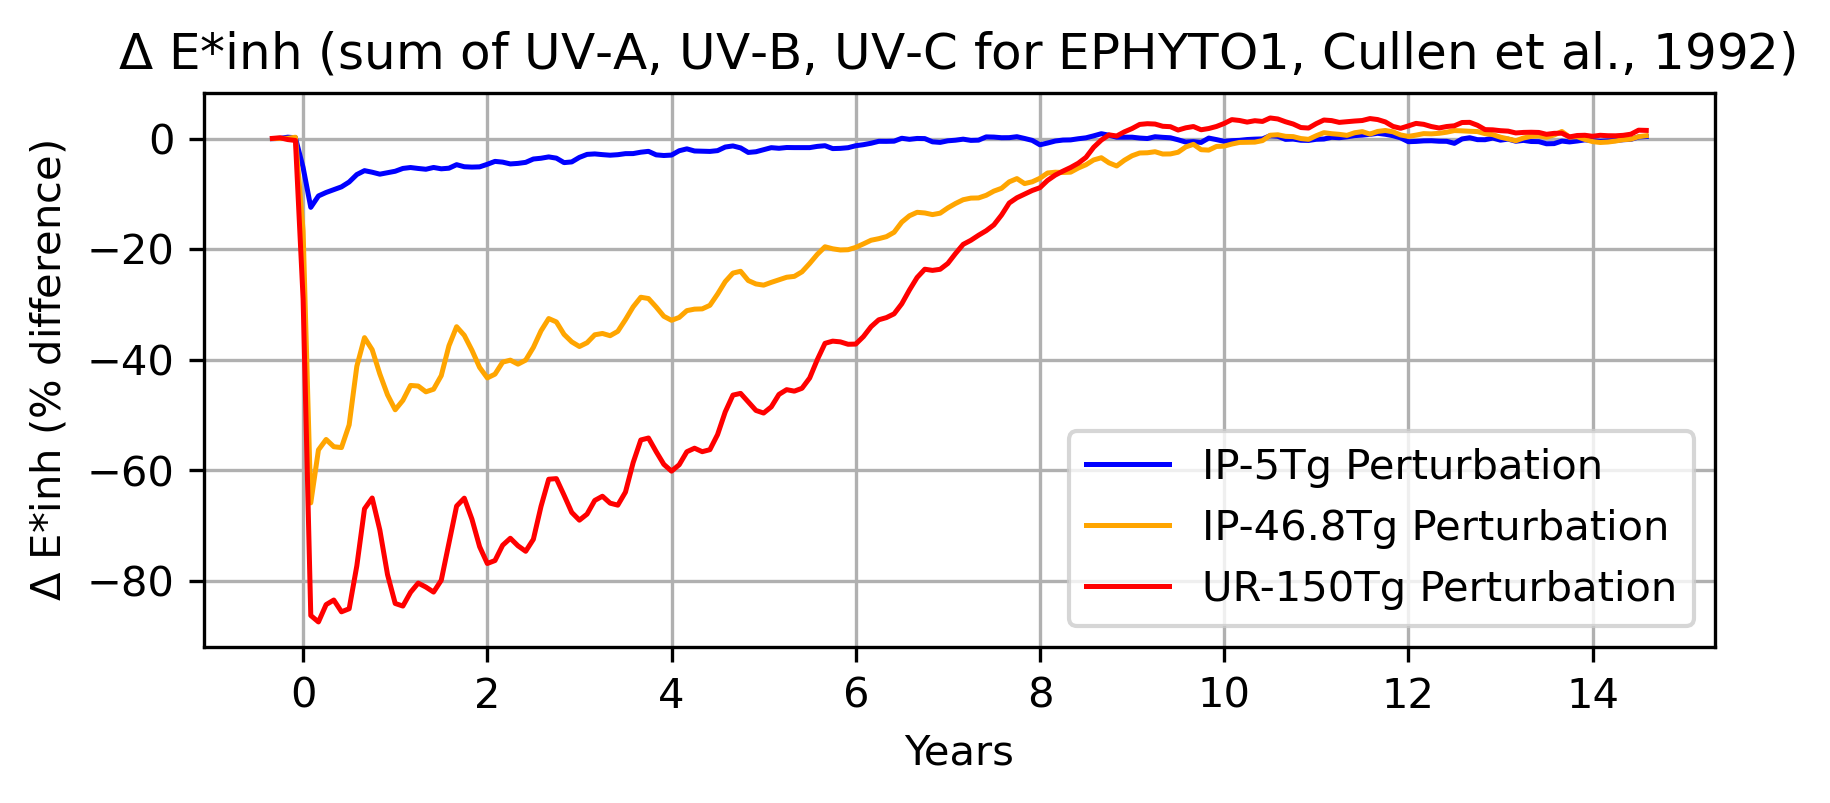

In [25]:
# make plot !

    
# plot sum of all - e*inh sum


plot_data={}
for case in these_cases:
    plot_data[case]={} #
    for VAR in these_variables:
        print(VAR)
        if 'UVA' in VAR: # UVA is the first...
            print('uva identification triggered?')
            plot_data[case]['global sst'] = np.array(monthly_data[case][VAR] ) # turn this into an array 
        else:
            plot_data[case]['global sst'] = np.array(monthly_data[case][VAR]) + plot_data[case]['global sst']
    
    
control_case='fosi_ip_5tg_01_ctluv'
perturbed_case='fosi_ip_5tg_01_alluv'
if True: # separate this from loop with variables 
    plt.figure(figsize=[6.5,2.4])
    varying_linewidth = 1.5
    nmonths = 180
    offset=5/12.0
    if True:
        final_plot_data = plot_data[perturbed_case]['global sst'][:nmonths] - plot_data[control_case]['global sst'][:nmonths]
        final_plot_data = final_plot_data * (plot_data[control_case]['global sst'][:nmonths]**-1) * 100.0
        ts = np.linspace(1, len(final_plot_data),len(final_plot_data)) * (1/12.0) - offset
        varying_linewidth = varying_linewidth - (varying_linewidth*0.2)
        plt.plot(ts,final_plot_data,color='blue',label='IP-5Tg Perturbation',linewidth = varying_linewidth)

        
control_case='fosi_ip_46p8_01_ctluv'
perturbed_case='fosi_ip_46p8_01_alluv'
if True: # separate this from loop with variables 
    #plt.figure(figsize=[6.5,2.4])
    varying_linewidth = 1.5
    nmonths = 180
    offset=5/12.0
    if True:
        final_plot_data = plot_data[perturbed_case]['global sst'][:nmonths] - plot_data[control_case]['global sst'][:nmonths]
        final_plot_data = final_plot_data * (plot_data[control_case]['global sst'][:nmonths]**-1) * 100.0
        ts = np.linspace(1, len(final_plot_data),len(final_plot_data)) * (1/12.0) - offset
        varying_linewidth = varying_linewidth - (varying_linewidth*0.2)
        plt.plot(ts,final_plot_data,color='orange',label='IP-46.8Tg Perturbation',linewidth = varying_linewidth)


control_case='fosi_ur_150tg_01_ctluv'
perturbed_case='fosi_ur_150tg_01_alluv'
if True: # separate this from loop with variables 
    #plt.figure(figsize=[6.5,2.4])
    varying_linewidth = 1.5
    nmonths = 180
    offset=5/12.0
    if True:
        final_plot_data = plot_data[perturbed_case]['global sst'][:nmonths] - plot_data[control_case]['global sst'][:nmonths]
        final_plot_data = final_plot_data * (plot_data[control_case]['global sst'][:nmonths]**-1) * 100.0
        ts = np.linspace(1, len(final_plot_data),len(final_plot_data)) * (1/12.0) - offset
        varying_linewidth = varying_linewidth - (varying_linewidth*0.2)
        plt.plot(ts,final_plot_data,color='r',label='UR-150Tg Perturbation',linewidth = varying_linewidth)


        
    


if True:    
    plt.ylabel('$\Delta$ E*inh (% difference)')
    plt.xlabel('Years')
    plt.title('$\Delta$ E*inh (sum of UV-A, UV-B, UV-C for EPHYTO1, Cullen et al., 1992) ')
    plt.legend(loc='best')
    plt.grid()
    plt.show()
    
    


In [39]:


#get files
these_cases=['fosi_ur_150tg_01_alluv','fosi_ur_150tg_01_ctluv','fosi_ip_46p8_01_alluv','fosi_ip_46p8_01_ctluv','fosi_ip_5tg_01_alluv','fosi_ip_5tg_01_ctluv']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_variables=['ATM_EPHYTO7UVA_NET','ATM_EPHYTO7UVB_NET','ATM_EPHYTO7UVC_NET']


files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

        
monthly_data={}
for case in these_cases:
    monthly_data[case]={}
    for var in these_variables:
        ds = xr.open_mfdataset(files[case][var])
        monthly_data[case][var] = compute_global_weighted_mean(ds,var=var)

ATM_EPHYTO7UVA_NET
uva identification triggered?
ATM_EPHYTO7UVB_NET
ATM_EPHYTO7UVC_NET
ATM_EPHYTO7UVA_NET
uva identification triggered?
ATM_EPHYTO7UVB_NET
ATM_EPHYTO7UVC_NET
ATM_EPHYTO7UVA_NET
uva identification triggered?
ATM_EPHYTO7UVB_NET
ATM_EPHYTO7UVC_NET
ATM_EPHYTO7UVA_NET
uva identification triggered?
ATM_EPHYTO7UVB_NET
ATM_EPHYTO7UVC_NET
ATM_EPHYTO7UVA_NET
uva identification triggered?
ATM_EPHYTO7UVB_NET
ATM_EPHYTO7UVC_NET
ATM_EPHYTO7UVA_NET
uva identification triggered?
ATM_EPHYTO7UVB_NET
ATM_EPHYTO7UVC_NET


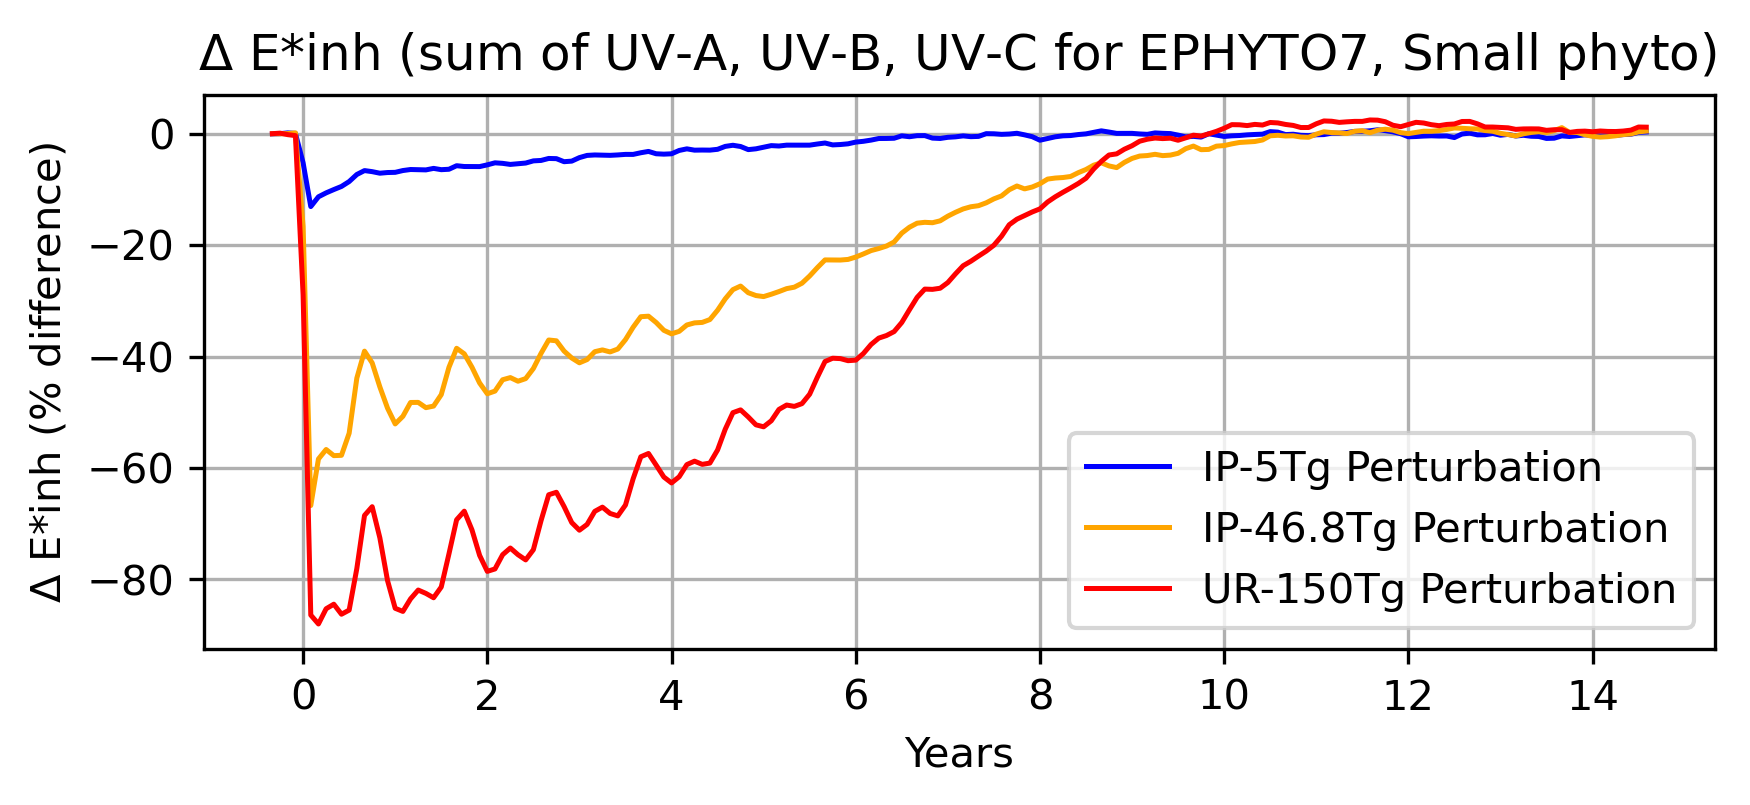

In [40]:

plot_data={}
for case in these_cases:
    plot_data[case]={} #
    for VAR in these_variables:
        print(VAR)
        if 'UVA' in VAR: # UVA is the first...
            print('uva identification triggered?')
            plot_data[case]['global sst'] = np.array(monthly_data[case][VAR] ) # turn this into an array 
        else:
            plot_data[case]['global sst'] = np.array(monthly_data[case][VAR]) + plot_data[case]['global sst']
    
    
control_case='fosi_ip_5tg_01_ctluv'
perturbed_case='fosi_ip_5tg_01_alluv'
if True: # separate this from loop with variables 
    plt.figure(figsize=[6.5,2.4])
    varying_linewidth = 1.5
    nmonths = 180
    offset=5/12.0
    if True:
        final_plot_data = plot_data[perturbed_case]['global sst'][:nmonths] - plot_data[control_case]['global sst'][:nmonths]
        final_plot_data = final_plot_data * (plot_data[control_case]['global sst'][:nmonths]**-1) * 100.0
        ts = np.linspace(1, len(final_plot_data),len(final_plot_data)) * (1/12.0) - offset
        varying_linewidth = varying_linewidth - (varying_linewidth*0.2)
        plt.plot(ts,final_plot_data,color='blue',label='IP-5Tg Perturbation',linewidth = varying_linewidth)

        
control_case='fosi_ip_46p8_01_ctluv'
perturbed_case='fosi_ip_46p8_01_alluv'
if True: # separate this from loop with variables 
    #plt.figure(figsize=[6.5,2.4])
    varying_linewidth = 1.5
    nmonths = 180
    offset=5/12.0
    if True:
        final_plot_data = plot_data[perturbed_case]['global sst'][:nmonths] - plot_data[control_case]['global sst'][:nmonths]
        final_plot_data = final_plot_data * (plot_data[control_case]['global sst'][:nmonths]**-1) * 100.0
        ts = np.linspace(1, len(final_plot_data),len(final_plot_data)) * (1/12.0) - offset
        varying_linewidth = varying_linewidth - (varying_linewidth*0.2)
        plt.plot(ts,final_plot_data,color='orange',label='IP-46.8Tg Perturbation',linewidth = varying_linewidth)


control_case='fosi_ur_150tg_01_ctluv'
perturbed_case='fosi_ur_150tg_01_alluv'
if True: # separate this from loop with variables 
    #plt.figure(figsize=[6.5,2.4])
    varying_linewidth = 1.5
    nmonths = 180
    offset=5/12.0
    if True:
        final_plot_data = plot_data[perturbed_case]['global sst'][:nmonths] - plot_data[control_case]['global sst'][:nmonths]
        final_plot_data = final_plot_data * (plot_data[control_case]['global sst'][:nmonths]**-1) * 100.0
        ts = np.linspace(1, len(final_plot_data),len(final_plot_data)) * (1/12.0) - offset
        varying_linewidth = varying_linewidth - (varying_linewidth*0.2)
        plt.plot(ts,final_plot_data,color='r',label='UR-150Tg Perturbation',linewidth = varying_linewidth)


        
    


if True:    
    plt.ylabel('$\Delta$ E*inh (% difference)')
    plt.xlabel('Years')
    plt.title('$\Delta$ E*inh (sum of UV-A, UV-B, UV-C for EPHYTO7, Small phyto) ')
    plt.legend(loc='best')
    plt.grid()
    plt.show()
    


In [41]:
#get files
these_cases=['fosi_ur_150tg_01_alluv','fosi_ur_150tg_01_ctluv','fosi_ip_46p8_01_alluv','fosi_ip_46p8_01_ctluv','fosi_ip_5tg_01_alluv','fosi_ip_5tg_01_ctluv']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_variables=['ATM_EPHYTO5UVA_NET','ATM_EPHYTO5UVB_NET','ATM_EPHYTO5UVC_NET']


files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

        
monthly_data={}
for case in these_cases:
    monthly_data[case]={}
    for var in these_variables:
        ds = xr.open_mfdataset(files[case][var])
        monthly_data[case][var] = compute_global_weighted_mean(ds,var=var)

ATM_EPHYTO5UVA_NET
uva identification triggered?
ATM_EPHYTO5UVB_NET
ATM_EPHYTO5UVC_NET
ATM_EPHYTO5UVA_NET
uva identification triggered?
ATM_EPHYTO5UVB_NET
ATM_EPHYTO5UVC_NET
ATM_EPHYTO5UVA_NET
uva identification triggered?
ATM_EPHYTO5UVB_NET
ATM_EPHYTO5UVC_NET
ATM_EPHYTO5UVA_NET
uva identification triggered?
ATM_EPHYTO5UVB_NET
ATM_EPHYTO5UVC_NET
ATM_EPHYTO5UVA_NET
uva identification triggered?
ATM_EPHYTO5UVB_NET
ATM_EPHYTO5UVC_NET
ATM_EPHYTO5UVA_NET
uva identification triggered?
ATM_EPHYTO5UVB_NET
ATM_EPHYTO5UVC_NET


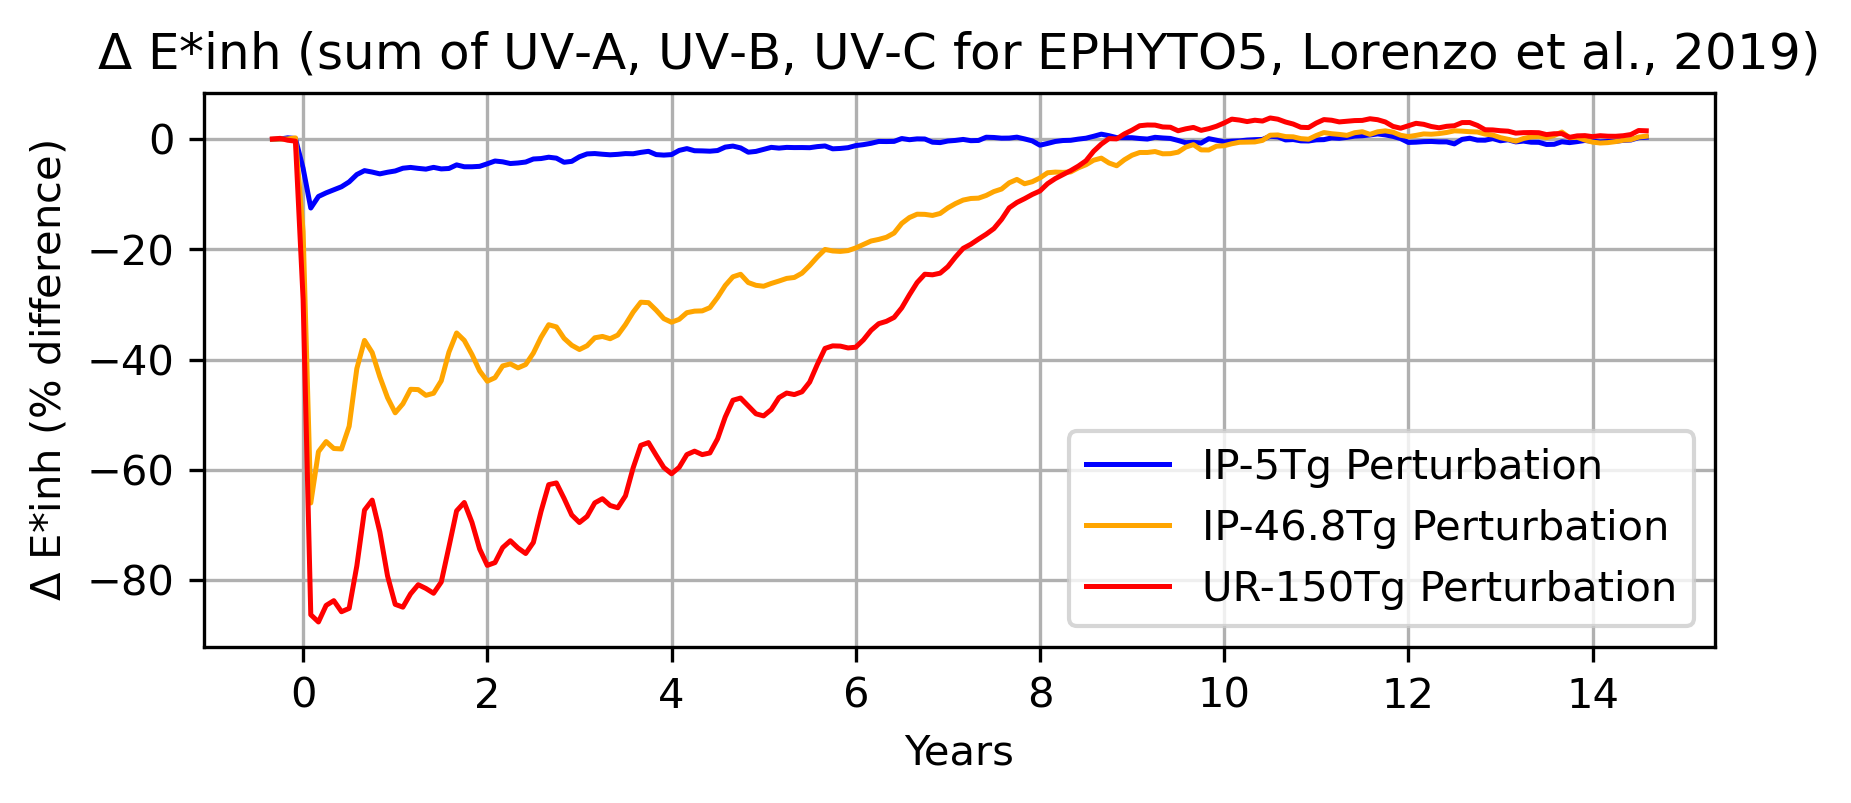

In [42]:

plot_data={}
for case in these_cases:
    plot_data[case]={} #
    for VAR in these_variables:
        print(VAR)
        if 'UVA' in VAR: # UVA is the first...
            print('uva identification triggered?')
            plot_data[case]['global sst'] = np.array(monthly_data[case][VAR] ) # turn this into an array 
        else:
            plot_data[case]['global sst'] = np.array(monthly_data[case][VAR]) + plot_data[case]['global sst']
    
    
control_case='fosi_ip_5tg_01_ctluv'
perturbed_case='fosi_ip_5tg_01_alluv'
if True: # separate this from loop with variables 
    plt.figure(figsize=[6.5,2.4])
    varying_linewidth = 1.5
    nmonths = 180
    offset=5/12.0
    if True:
        final_plot_data = plot_data[perturbed_case]['global sst'][:nmonths] - plot_data[control_case]['global sst'][:nmonths]
        final_plot_data = final_plot_data * (plot_data[control_case]['global sst'][:nmonths]**-1) * 100.0
        ts = np.linspace(1, len(final_plot_data),len(final_plot_data)) * (1/12.0) - offset
        varying_linewidth = varying_linewidth - (varying_linewidth*0.2)
        plt.plot(ts,final_plot_data,color='blue',label='IP-5Tg Perturbation',linewidth = varying_linewidth)

        
control_case='fosi_ip_46p8_01_ctluv'
perturbed_case='fosi_ip_46p8_01_alluv'
if True: # separate this from loop with variables 
    #plt.figure(figsize=[6.5,2.4])
    varying_linewidth = 1.5
    nmonths = 180
    offset=5/12.0
    if True:
        final_plot_data = plot_data[perturbed_case]['global sst'][:nmonths] - plot_data[control_case]['global sst'][:nmonths]
        final_plot_data = final_plot_data * (plot_data[control_case]['global sst'][:nmonths]**-1) * 100.0
        ts = np.linspace(1, len(final_plot_data),len(final_plot_data)) * (1/12.0) - offset
        varying_linewidth = varying_linewidth - (varying_linewidth*0.2)
        plt.plot(ts,final_plot_data,color='orange',label='IP-46.8Tg Perturbation',linewidth = varying_linewidth)


control_case='fosi_ur_150tg_01_ctluv'
perturbed_case='fosi_ur_150tg_01_alluv'
if True: # separate this from loop with variables 
    #plt.figure(figsize=[6.5,2.4])
    varying_linewidth = 1.5
    nmonths = 180
    offset=5/12.0
    if True:
        final_plot_data = plot_data[perturbed_case]['global sst'][:nmonths] - plot_data[control_case]['global sst'][:nmonths]
        final_plot_data = final_plot_data * (plot_data[control_case]['global sst'][:nmonths]**-1) * 100.0
        ts = np.linspace(1, len(final_plot_data),len(final_plot_data)) * (1/12.0) - offset
        varying_linewidth = varying_linewidth - (varying_linewidth*0.2)
        plt.plot(ts,final_plot_data,color='r',label='UR-150Tg Perturbation',linewidth = varying_linewidth)


        
    


if True:    
    plt.ylabel('$\Delta$ E*inh (% difference)')
    plt.xlabel('Years')
    plt.title('$\Delta$ E*inh (sum of UV-A, UV-B, UV-C for EPHYTO5, Lorenzo et al., 2019) ')
    plt.legend(loc='best')
    plt.grid()
    plt.show()
    
    
